# **CA4 @ AI Spring 2025**
# Convolutional vs. Fully Connected Neural Networks

- **Name:**  Deniz mostafazadegan
- **Student ID:**  810102603

---
Your submission should be named using the following format: `AI_CA4_LASTNAME_STUDENTID.ipynb`.

---

 *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says `WRITE YOUR ANSWER HERE` with your actual answer.
---
If you have any further questions or concerns, contact the TAs via email or Telegram.

# Introduction
In this assignment, you will compare fully connected neural networks with convolutional neural networks to evaluate whether convolutional architectures offer superior performance—and understand the reasons behind any observed differences.

**Important Note:**

Before you begin, please make sure to review the accompanying PyTorch tutorial provided alongside this file.

## Colab Setup

If you are running this notebook on Google Colab, you can mount your Google Drive using the following code to access or upload files directly from your Drive.

## Device

As demonstrated in the PyTorch tutorial, PyTorch enable you to run your code on GPU to accelerate computations.

In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Dataset

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [2]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])


In [4]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torchvision

batch_size = 512

initial_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainset, valset = random_split(initial_trainset, [45000, 5000])

# YOUR CODE HERE

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0 , pin_memory=True)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=0 , pin_memory=True)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0 , pin_memory=True )


100%|██████████| 170M/170M [00:03<00:00, 47.7MB/s]


# 🎯
## Dataloader :

* Loads data in batches
* Shuffles the data
* Loads data in parallel using multiple workers
* Automatically provides an iterator to loop through the dataset during training.

## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

In [5]:
# inverse the normilize transform to restore the original data
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)

    def __call__(self, tensor, gray=False, coeff=(0.3, 0.59, 0.11)):
      # YOUR CODE HERE
        if tensor.device != self.mean.device:
            self.mean = self.mean.to(tensor.device)
            self.std = self.std.to(tensor.device)
        return tensor * self.std + self.mean



In [6]:
# YOUR CODE HERE
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])


dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)


In [7]:
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

class_images = {class_id: [] for class_id in range(10)}
for img, label in dataset:
    if len(class_images[label]) < 5:
        class_images[label].append(img)
    if all(len(v) == 5 for v in class_images.values()):
        break

norminv = UnNormalize(mean=(0.491, 0.482, 0.446), std=(0.247, 0.243, 0.261))


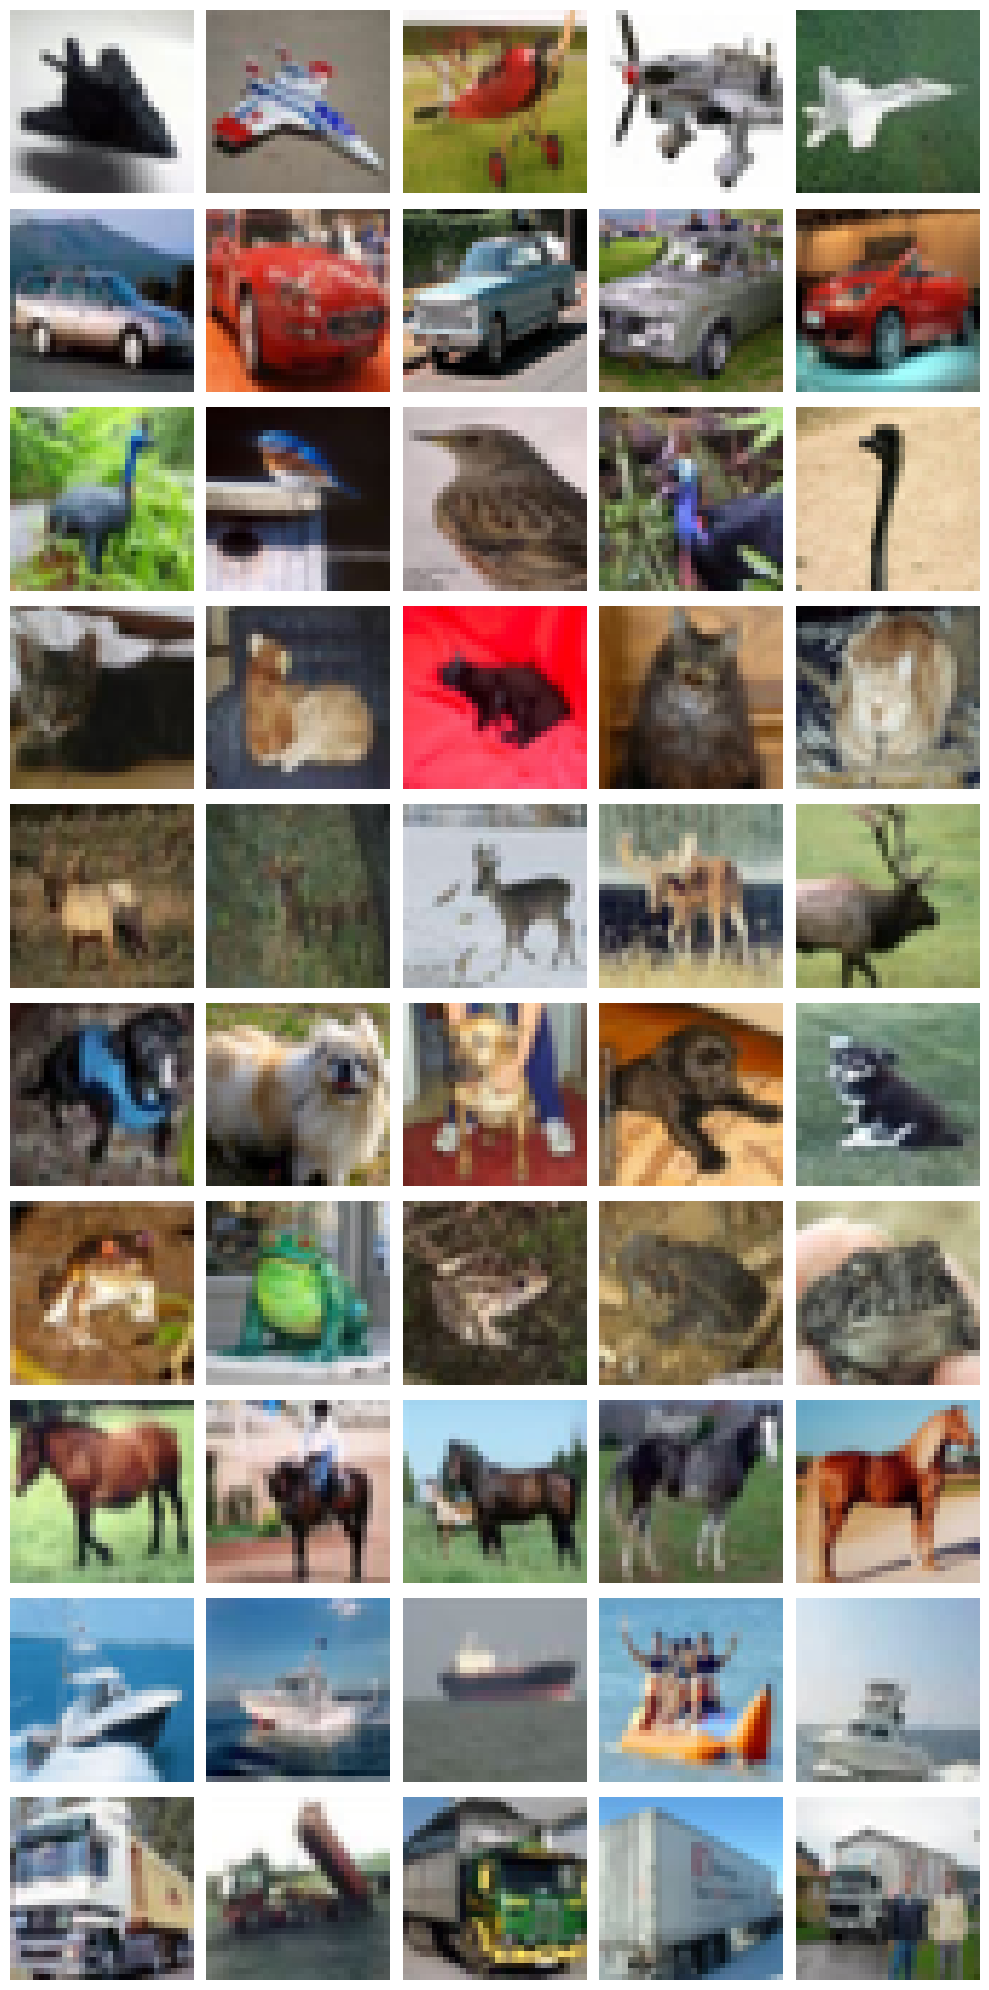

In [8]:
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
for class_id in range(10):
    for i in range(5):
        img = norminv(class_images[class_id][i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[class_id, i].imshow(img)
        axes[class_id, i].axis('off')
        if i == 0:
            axes[class_id, i].set_ylabel(classes[class_id], fontsize=10)

plt.tight_layout()
plt.show()

# Fully Connected Neural Netwrok

Your first task is to build a fully connected neural network with PyTorch. To achieve this, it is recommended that you familiarize yourself with the following PyTorch components and incorporate them into your network architecture:

* [`nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)
* [`nn.Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
* [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
* [`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
* [`nn.Dropout`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
* [`nn.Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

In the provided template below, the final layer of the model should be defined separately and assigned the name `linear`, as it will be referenced in a later section of this assignment.

To ensure a fair comparison with convolutional neural networks (CNNs), both models should have approximately the same number of trainable parameters. Specifically, the fully connected model should contain **33,500,000 ± 500,000** trainable parameters.

You will calculate the exact number of trainable parameters in the following subsection to ensure this requirement is met.




In [9]:
import torch
import numpy as np
import torchvision
import torch.nn as nn
import math
from torchvision import transforms

class FullyConnectedNetwork(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=10):
        super(FullyConnectedNetwork, self).__init__()
        # YOUR CODE HERE

        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(3072, 4096),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(4096, 1024),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.linear = nn.Linear(1024, 10)


    def forward(self, x):
        # YOUR CODE HERE
        x = self.flatten(x)         # to vector
        x = self.fc_layers(x)       # layers
        x = self.linear(x)          # final output
        return x

# 🎯
### Dropout is a regularization technique used in neural networks to prevent overfitting.
#### During training, Dropout:
* Randomly "drops out" (30) a percentage of neurons in a layer.


## Trainable params

Based on the defined architecture, manually calculate the total number of trainable parameters:

## ✖️ 🟰  ➗ ➕
( in_features × out_features ) + biases
* Layer 1 =>  3072 × 4096  + 4096 = 12,587,008
* Layer 2 =>  4096 × 4096  + 4096 = 16,781,312
* Layer 3 =>  4096 × 1024  + 1024 = 4,195,328
* Layer 4 =>  1024× 10 + 10 =  10,250
* Sum => 33,573,898


Once you have completed your hand calculation, you can verify your result by running the following cell:

In [10]:
from torchsummary import summary

## Train

### Model Instantiation

Create an instance of your model and move it to your selected device (CPU or GPU). Refer to the PyTorch-tutorial notebook for guidance on how to perform this operation.

In [11]:
# YOUR CODE HERE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FullyConnectedNetwork()
model = model.to(device)

summary(FullyConnectedNetwork().to(device), input_size=(3, 32, 32));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                 [-1, 4096]      12,587,008
              ReLU-3                 [-1, 4096]               0
           Dropout-4                 [-1, 4096]               0
            Linear-5                 [-1, 4096]      16,781,312
              ReLU-6                 [-1, 4096]               0
           Dropout-7                 [-1, 4096]               0
            Linear-8                 [-1, 1024]       4,195,328
              ReLU-9                 [-1, 1024]               0
          Dropout-10                 [-1, 1024]               0
           Linear-11                   [-1, 10]          10,250
Total params: 33,573,898
Trainable params: 33,573,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Fo

### Criterion & Optimizer


To train a neural network, we require a **loss function** (referred to as the *criterion*) to quantify the difference between the model's predictions and the true labels. This loss is then used to compute the gradients of the model parameters.

In addition, an **optimization algorithm** is needed to update the model's parameters using the calculated gradients, in order to minimize the loss over time.

You are encouraged to read about the following PyTorch components:

* [`nn.CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
* [`torch.optim.Adam`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

In [12]:
import torch.nn as nn
import torch.optim as optim
# YOUR CODE HERE
criterion = nn.CrossEntropyLoss()

# YOUR CODE HERE
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 🔃 CrossEntropyLoss
Used in multi-class classification problems Tells the model how well it predicted the correct class.


Loss=−log(py)      (the true class is y)
* The lower the loss → the higher the predicted probability for the correct class.

MSELoss	=>  for	Regression task ,Simple, interpretable , not for multi_class

## 📶 Adam Optimizer
updates model weights using :
* Momentum : (Helps keep updates moving in the right direction)(Averages gradients over time) => (Smooths out updates over time)(Fast , Smooth , Less sensitive to noisy gradients)
* Adaptive learning rates : (Scales learning rates individually for each parameter) => (Each parameter gets its own learning rate based on past gradients)


## ↔ Adam vs SGD
* Learning rate : SGD (Fixed for all parameters)
* Speed of convergence : SGD is slower
* Momentum handling : SGD (optimel) - adam(built in)
* Use in deep networks : adam(Performs well)


Adam is like driving a car with smart cruise control — it adjusts how fast or slow each wheel should go based on road conditions (gradients), making the ride (training) smoother and faster.

### Train loop

Train your model

Tasks:
- Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- save train/validation loss and accuracy (of each epoch) in an array for later usage

In [13]:
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct, total

def train_epoch(net: torch.nn.Module, criterion: torch.nn.Module, optimizer: torch.optim.Optimizer ,dataloader: torch.utils.data.DataLoader):
    """
    Trains the neural network for a single epoch.

    Args:
        net (torch.nn.Module): The neural network model to be trained.
        criterion (torch.nn.Module): The loss function used to compute the training loss.
        optimizer (torch.optim.Optimizer): The optimization algorithm used to update model parameters.
        dataloader (torch.utils.data.DataLoader): DataLoader providing the training data in batches.

    Returns:
        tuple:
            - avg_loss (float): The average loss across all batches in the epoch.
            - accuracy (float): The classification accuracy (in percentage) over the entire dataset for the epoch.

    Notes:
        - The `criterion` computes the loss between the model's predictions and the true labels.
        - The `optimizer` updates the model's parameters based on the computed gradients to minimize the loss.
    """

    # YOUR CODE HERE

    net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()   # remove last g
        outputs = net(inputs)   # calculate new g
        loss = criterion(outputs, labels)   # update g
        loss.backward()   # update w
        optimizer.step()  #repeat in batch

        running_loss += loss.item() * inputs.size(0)
        c, t = compute_accuracy(outputs, labels)
        correct += c
        total += t

    avg_loss = running_loss / total
    accuracy = correct / total * 100
    return avg_loss, accuracy


In [14]:
def eval_epoch(net: torch.nn.Module, criterion: torch.nn.Module, dataloader: torch.utils.data.DataLoader, test_mode: bool = False):
    """
    Evaluates the neural network on a validation or test dataset for one epoch.
    """
    net.eval()

    # YOUR CODE HERE

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            c, t = compute_accuracy(outputs, labels)
            correct += c
            total += t

    avg_loss = running_loss / total
    accuracy = correct / total * 100
    return avg_loss, accuracy

As previously mentioned, ensuring a fair comparison between models requires consistency in certain aspects of the training setup. One key factor is the number of **trainable parameters**, and another is the number of times the model processes the entire dataset—referred to as an **epoch**.

To maintain consistency in training duration across models, **do not modify** the `epochs` variable defined below.


In [15]:
epochs = 60 # Do not modify

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}


for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, criterion, optimizer, trainloader)
    val_loss, val_acc = eval_epoch(model, criterion, valloader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"(Epoch {epoch + 1} / {epochs}) train loss:{train_loss: .4f}; train acc:{train_acc: .2f}%; val loss:{val_loss: .4f}; val_acc:{val_acc: .2f}%")

(Epoch 1 / 60) train loss: 1.8656; train acc: 33.86%; val loss: 1.6151; val_acc: 43.40%
(Epoch 2 / 60) train loss: 1.5937; train acc: 43.43%; val loss: 1.4930; val_acc: 47.94%
(Epoch 3 / 60) train loss: 1.4884; train acc: 47.24%; val loss: 1.4326; val_acc: 49.78%
(Epoch 4 / 60) train loss: 1.4300; train acc: 49.67%; val loss: 1.4097; val_acc: 50.00%
(Epoch 5 / 60) train loss: 1.3668; train acc: 51.77%; val loss: 1.4145; val_acc: 51.30%
(Epoch 6 / 60) train loss: 1.3193; train acc: 53.02%; val loss: 1.3593; val_acc: 52.40%
(Epoch 7 / 60) train loss: 1.2761; train acc: 54.75%; val loss: 1.3650; val_acc: 52.10%
(Epoch 8 / 60) train loss: 1.2459; train acc: 55.60%; val loss: 1.3557; val_acc: 52.74%
(Epoch 9 / 60) train loss: 1.2070; train acc: 57.05%; val loss: 1.3502; val_acc: 52.78%
(Epoch 10 / 60) train loss: 1.1711; train acc: 58.30%; val loss: 1.3481; val_acc: 53.74%
(Epoch 11 / 60) train loss: 1.1357; train acc: 59.68%; val loss: 1.3332; val_acc: 54.70%
(Epoch 12 / 60) train loss: 1.

### Save Model

Save the trained model for use in subsequent sections to avoid retraining it later.


In [16]:
torch.save(model.state_dict(), "fully-connected.pth")

In [17]:
# To load the previously saved model, simply uncomment the code below.
model.load_state_dict(torch.load('fully-connected.pth'))  ؟؟؟؟؟؟

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

## 📉 Plots

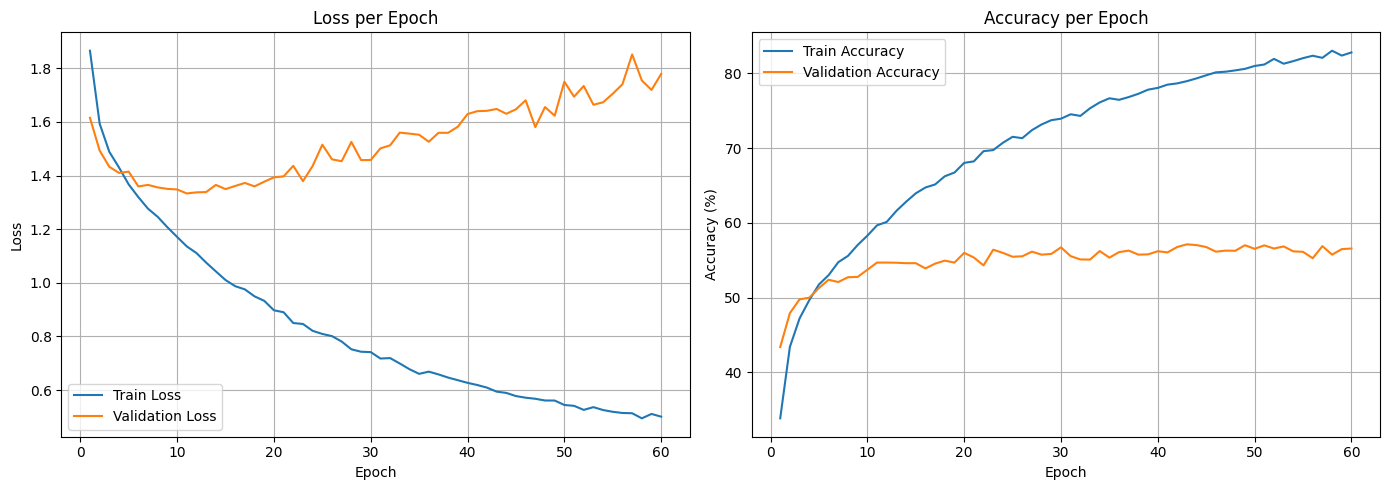

In [18]:
# YOUR CODE HERE

import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# 📉 Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 📈 Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 📈Analysis

* Training loss decreases steadily, showing that the model is fitting the data.
* Validation accuracy plateaus early, suggesting potential overfitting — the model memorizes training data

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `60%`

In [19]:
# YOUR CODE HERE

model.eval()

test_loss, test_acc = eval_epoch(model, criterion, testloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")


Test Loss: 1.7869
Test Accuracy: 56.18%


# Convolutional Neural Network

## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

 You are encouraged to learn about the following core components commonly used in convolutional neural networks:

* [`nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
* [`nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

**Reminder**: The model you define should contain 33,500,000 ± 500,000 trainable parameters.

In [20]:
import torch
import torch.nn as nn

class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128x8x8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 256x4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(4096, 5632),
            nn.ReLU(),
            nn.Dropout(0.55),

            nn.Linear(5632, 1408),
            nn.ReLU(),
            nn.Dropout(0.55),

            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.55),
        )

        self.linear = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        x = self.linear(x)
        return x


## Trainable params

Based on the defined architecture, manually calculate the total number of trainable parameters:

## ✖️ 🟰  ➗ ➕
* Conv2d(in, out, k)	= (in × out × k × k) + out
* Linear(in, out)	= in × out + out
* BatchNorm2d(ch)	= 2 × ch (a,b)

* layer 1 :
    * Conv2d(3, 64, 3) : 64 × (3×3×3 + 1) = 64 × 28 = 1,792
    * Conv2d(64, 64, 3) : 64 × (64×3×3 + 1) = 64 × 577 = 36,928
* layer 2 :
    * Conv2d(64, 128, 3) = 128 × (64×3×3 + 1) = 128 × 577 = 73,856
    * Conv2d(128, 128, 3) = 128 × (128×3×3 + 1) = 128 × 1153 = 147,584
    * Conv2d(128, 128, 3) = 128 × (128×3×3 + 1) = 128 × 1153 = 147,584

* layer 3 :
    * Conv2d(128, 256, 3) =  256 × (128×3×3 + 1) = 256 × 1153 = 295,168
    * Conv2d(256, 256, 3) = 256 × (256×3×3 + 1) = 256 × 2305 = 590,080
    * Conv2d(256, 256, 3) =  256 × (256×3×3 + 1) = 256 × 2305 = 590,080
* layer 4 :
    * Linear(4096, 5632) = 5632 × (4096 + 1) = 5632 × 4097 = 23,070,304
* layer 5 :
    * Linear(5632, 1408) = 1408 × (5632 + 1) = 1408 × 5633 = 7,936,064
* layer 6 :
    * Linear(1408, 512) = 512 × (1408 + 1) = 512 × 1409 = 721,408
* layer 7 :
    * Linear(512, 10) = 10 × (512 + 1) = 10 × 513 = 5,130
    


Once you have completed your hand calculation, you can verify your result by running the following cell:

In [21]:
from torchsummary import summary


## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [22]:
# YOUR CODE HERE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepCNN()
model = model.to(device)

summary(DeepCNN().to(device), input_size=(3, 32, 32))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          36,928
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6          [-1, 128, 16, 16]          73,856
              ReLU-7          [-1, 128, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]         147,584
              ReLU-9          [-1, 128, 16, 16]               0
           Conv2d-10          [-1, 128, 16, 16]         147,584
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         295,168
             ReLU-14            [-1, 25

### Criterion & Optimizer

Define `criterion` and `optimizer`

In [23]:
# YOUR CODE HERE
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

### Train loop

Train your model

Tasks:
- Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- save train/validation loss and accuracy (of each epoch) in an array for later usage

In [24]:
def train_epoch(net, criterion, optimizer, dataloader, device=torch.device('cpu')):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


In [25]:
def eval_epoch(net, criterion, dataloader, device=torch.device('cpu')):
    net.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


In [26]:
epochs = 60 # Do not modify
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, criterion, optimizer, trainloader ,  device=device)
    val_loss, val_acc = eval_epoch(model, criterion, valloader ,  device=device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"(Epoch {epoch + 1} / {epochs}) train loss:{train_loss: .4f}; train acc:{train_acc: .2f}%; val loss:{val_loss: .4f}; val_acc:{val_acc: .2f}%")

(Epoch 1 / 60) train loss: 2.0921; train acc: 20.23%; val loss: 1.7989; val_acc: 32.16%
(Epoch 2 / 60) train loss: 1.6698; train acc: 36.22%; val loss: 1.4595; val_acc: 43.96%
(Epoch 3 / 60) train loss: 1.3933; train acc: 47.86%; val loss: 1.2067; val_acc: 54.92%
(Epoch 4 / 60) train loss: 1.1736; train acc: 57.32%; val loss: 1.0198; val_acc: 62.56%
(Epoch 5 / 60) train loss: 1.0218; train acc: 63.60%; val loss: 0.9320; val_acc: 66.80%
(Epoch 6 / 60) train loss: 0.8791; train acc: 69.22%; val loss: 0.8638; val_acc: 67.74%
(Epoch 7 / 60) train loss: 0.7824; train acc: 72.81%; val loss: 0.7922; val_acc: 72.22%
(Epoch 8 / 60) train loss: 0.6818; train acc: 76.57%; val loss: 0.7258; val_acc: 75.16%
(Epoch 9 / 60) train loss: 0.6044; train acc: 79.35%; val loss: 0.6875; val_acc: 76.38%
(Epoch 10 / 60) train loss: 0.5387; train acc: 81.54%; val loss: 0.6711; val_acc: 77.34%
(Epoch 11 / 60) train loss: 0.4643; train acc: 84.05%; val loss: 0.6800; val_acc: 77.96%
(Epoch 12 / 60) train loss: 0.

### Save Model

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [27]:
torch.save(model.state_dict(), "cnn.pth")

In [37]:
# To load the previously saved model, simply uncomment the code below.
model.load_state_dict(torch.load('cnn.pth'))

<All keys matched successfully>

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

## 📉 Plots

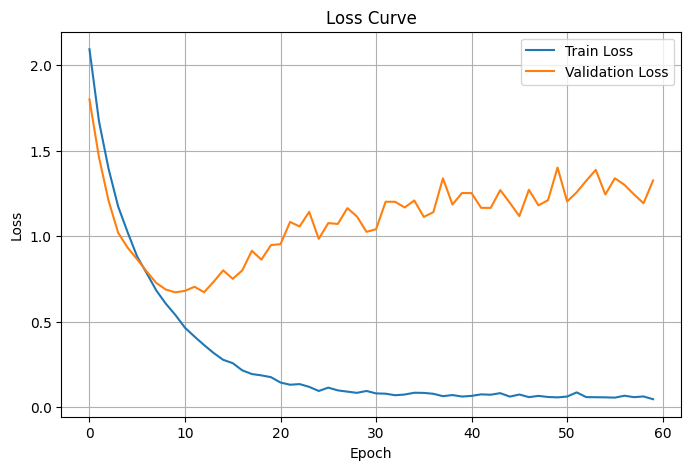

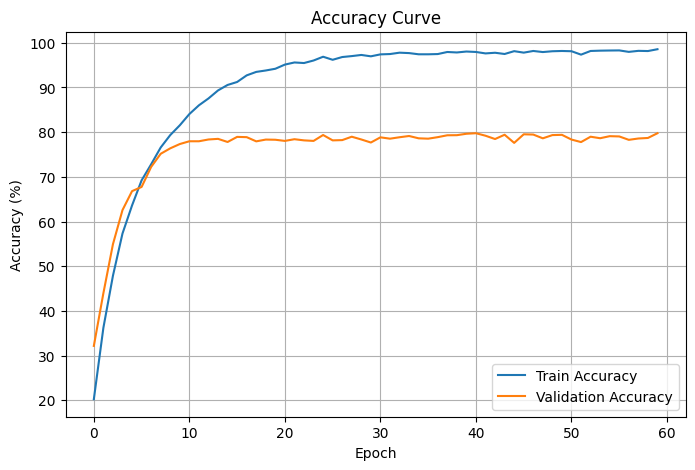

In [29]:
# YOUR CODE HERE

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# رسم نمودار دقت (Accuracy)
plt.figure(figsize=(8, 5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


## 📈Analysis

In [30]:
# YOUR CODE HERE

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `80%`

In [31]:
# YOUR CODE HERE
test_loss, test_acc = eval_epoch(model, criterion, testloader, device=device)
print(f"🎯 Test Accuracy: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

🎯 Test Accuracy: 79.53% | Test Loss: 1.4160


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

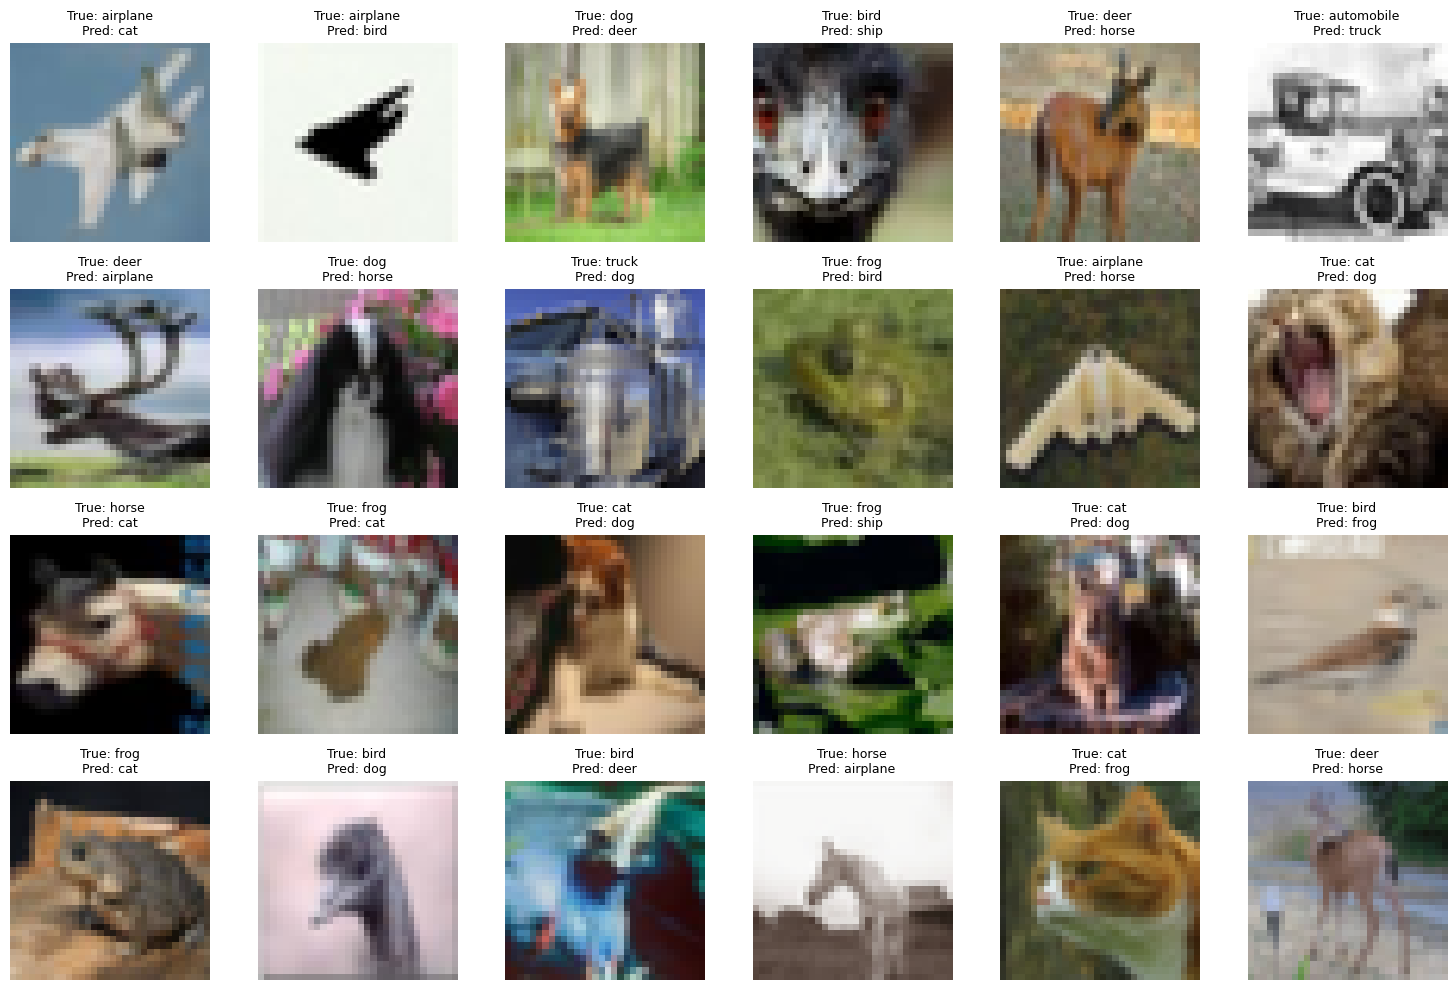

In [32]:
# YOUR CODE HERE

wrong_preds = []

model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        wrong_mask = preds != labels
        for img, true_lbl, pred_lbl in zip(inputs[wrong_mask], labels[wrong_mask], preds[wrong_mask]):
            wrong_preds.append((img.cpu(), true_lbl.cpu(), pred_lbl.cpu()))
        if len(wrong_preds) >= 24:
            break

fig, axes = plt.subplots(4, 6, figsize=(15, 10))
for idx, (img, true_lbl, pred_lbl) in enumerate(wrong_preds[:24]):
    img = norminv(img)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    ax = axes[idx // 6, idx % 6]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"True: {classes[true_lbl]}\nPred: {classes[pred_lbl]}", fontsize=9)

plt.tight_layout()
plt.show()


## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(45000, N)` saved in a variable (for later usage)

- **Hint:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [33]:
# YOUR CODE HERE
trainloader_no_shuffle = torch.utils.data.DataLoader(
    trainset,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

def get_feature_space(model, dataloader, device):
    model.eval()
    all_features = []

    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to(device)
            feats = model.features(inputs)
            feats = model.classifier(feats)
            all_features.append(feats.cpu())

    return torch.cat(all_features, dim=0)


train_features = get_feature_space(model, trainloader_no_shuffle, device)
print(train_features.shape)


torch.Size([45000, 512])


### K Nearest Neighbor in feature space

We already have calculated the feature spaces for trainset ($S$) in the previous section. Now we follow these steps to explore the featre space:

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

In [34]:
feature_space = None
# YOUR CODE HERE
correct_samples = []
model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        mask = preds == labels
        for img, label, pred in zip(inputs[mask], labels[mask], preds[mask]):
            correct_samples.append((img.cpu(), label.cpu()))
            if len(correct_samples) == 5:
                break
        if len(correct_samples) == 5:
            break


In [35]:
query_features = []
for img, _ in correct_samples:
    img = img.unsqueeze(0).to(device)
    feat = model.features(img)
    feat = model.classifier(feat).cpu().squeeze(0)
    query_features.append(feat)


In [38]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=5)
knn.fit(train_features)  # S

distances, indices = knn.kneighbors(torch.stack(query_features).detach().numpy())


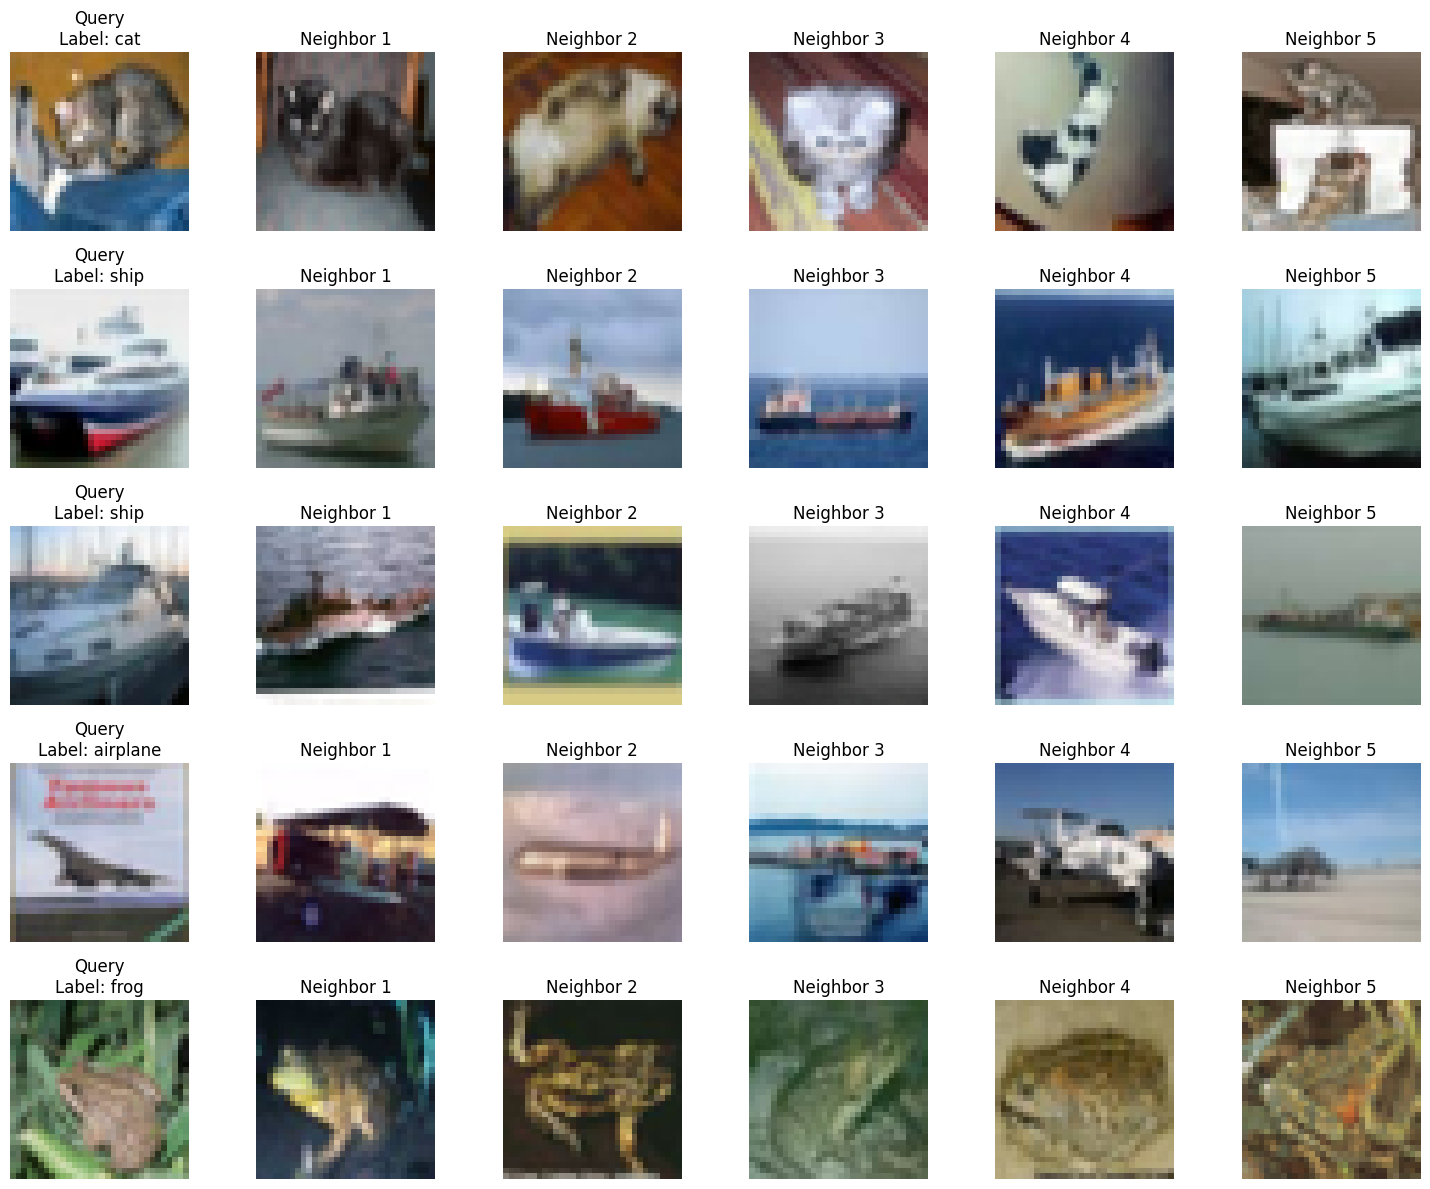

In [39]:
fig, axes = plt.subplots(5, 6, figsize=(15, 12))

for i in range(5):
    query_img, true_label = correct_samples[i]

    axes[i, 0].imshow(norminv(query_img).permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f"Query\nLabel: {classes[true_label]}")
    axes[i, 0].axis('off')

    for j in range(5):
        idx = indices[i][j]
        neighbor_img = trainloader_no_shuffle.dataset[idx][0]
        axes[i, j+1].imshow(norminv(neighbor_img).permute(1, 2, 0).numpy())
        axes[i, j+1].set_title(f"Neighbor {j+1}")
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.show()


## ⁉️What similarities exist between test samples and their nearest neighbors?
🔑
* Visual: such as similar colors, textures, or orientations
* Semantic: meaning they belong to the same category/class or share meaningful characteristics (like multiple types of dogs).

## ⁉️Why does this closeness happen in the feature space?
🔑


In the feature space, the model maps images to high-level representations. So:
* Images with similar meaningful patterns are placed closer together, even if their raw pixels are different.
* The model learns to focus on abstract, semantic features rather than low-level details.


## ⁉️What is the relationship between train and test data in this space?
🔑
* If the model is well-trained, test images will be placed close to similar train images in the feature space.
* The better this alignment, the better the model performs on classification.


🔑


* Feature space reflects the model’s understanding of image meaning. Closeness there indicates how well the model captures semantic similarity, not just appearance. This is key to deep learning's success in visual tasks.


### TSNE

Let's follow these steps to explore feature space even more:

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now we have a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now we have a vector of size `(M, 2)`)
4. Visualize the points in a 2D plane (Set color of each point based on it's class)


In [43]:
from sklearn.manifold import TSNE

model.eval()
feature_space = []
feature_labels = []

with torch.no_grad():
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        features = model.classifier(model.features(inputs))
        feature_space.append(features.cpu())
        feature_labels.append(labels)

feature_space = torch.cat(feature_space, dim=0)
train_labels = torch.cat(feature_labels, dim=0)


indices = np.random.randint(0, len(feature_space), 2000)
sampled_features = feature_space[indices]  # Rename for clarity

tsne = TSNE(n_components=2, random_state=42)
reduced_space = tsne.fit_transform(sampled_features.detach().numpy())

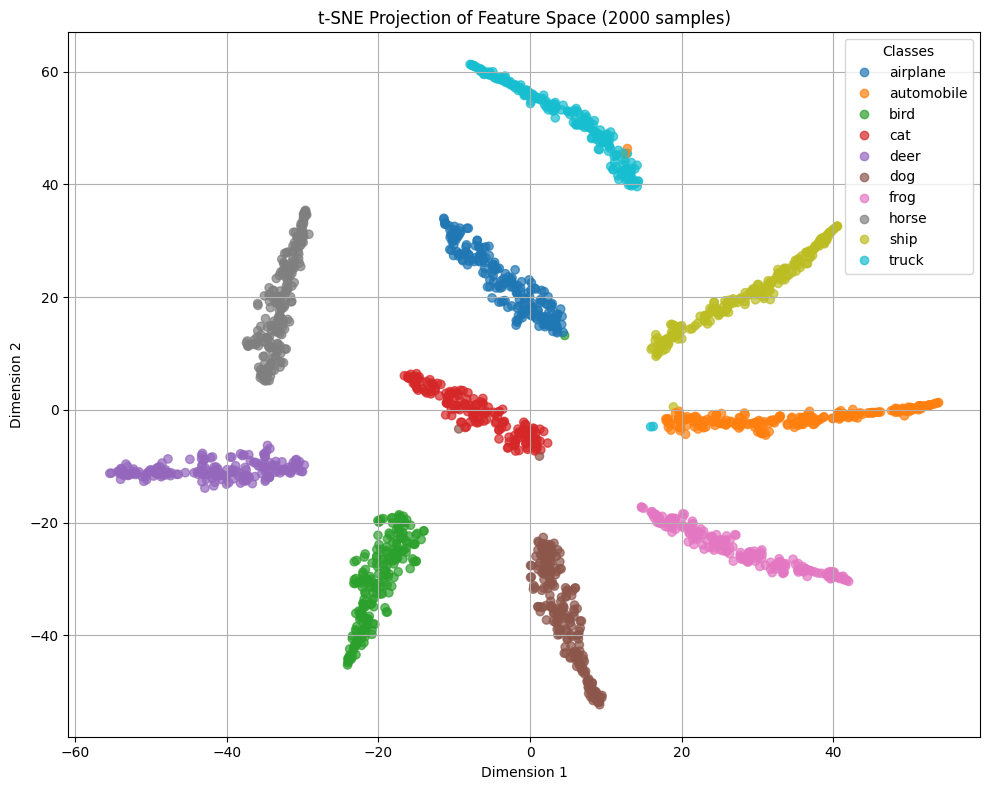

In [44]:
# YOUR CODE HERE

labels_subset = train_labels[indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_space[:, 0], reduced_space[:, 1], c=labels_subset, cmap='tab10', alpha=0.7)
plt.title("t-SNE Projection of Feature Space (2000 samples)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")


legend_labels = [classes[i] for i in range(10)]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title="Classes")

plt.grid(True)
plt.tight_layout()
plt.show()



## ⁉️What does the t-SNE plot show about feature space and clustering?
🔑
When we reduce the feature space to 2D using t-SNE, we usually see:


* Clear clusters: Samples from the same class (e.g., all dogs) group closely together.
* Separation: Different classes (e.g., airplanes vs. cats) form separate clusters.

🔑
Good clustering in the t-SNE plot means:


* The model has learned a useful and meaningful representation of the data.
* The feature space has structure that reflects real class groupings.
* This is a sign of strong generalization and model understanding.

### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

In [45]:
image = trainset[3][0]

## ⁉️What can we learn from feature maps?
🔑
* How the model "sees" the image
You can understand what the model is focusing on at each layer.
* Class-specific behavior
You can compare feature maps across classes to see how the model reacts differently.
* They help us understand the internal process of a CNN.

Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children()[:2])
)
intermediate_output = clipped(input)
```



In [46]:
# YOUR CODE HERE
input_tensor = image.unsqueeze(0).to(device)
clipped = nn.Sequential(*list(model.features.children())[:4])
intermediate_output = clipped(input_tensor)

In [47]:
intermediate_output.shape

torch.Size([1, 64, 32, 32])

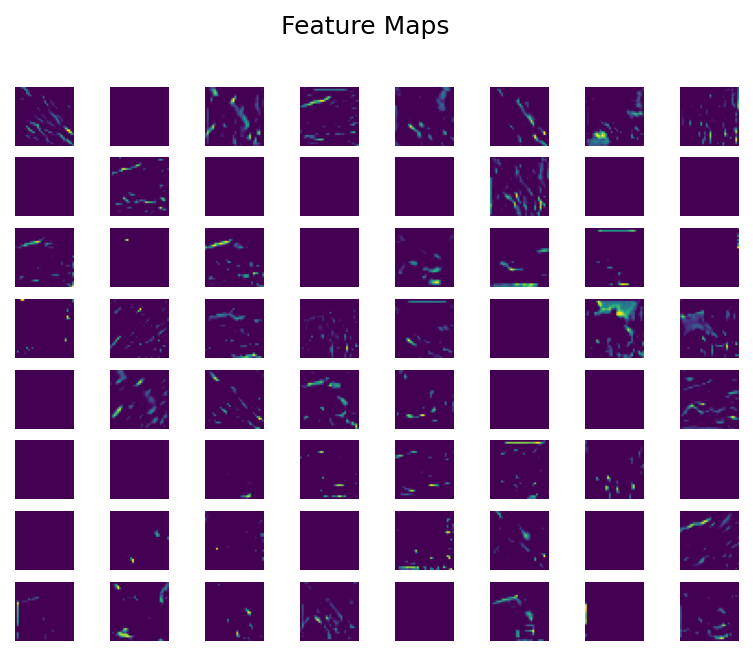

In [48]:
import matplotlib.pyplot as plt

def plot_intermediate_output(result, title=None):
    """
    Plots the intermediate output of shape
    N_FILTERS x H x W
    """
    plt.rcParams['figure.dpi'] = 150
    n_filters = result.shape[1]
    N = int(math.sqrt(n_filters))
    M = (n_filters + N - 1) // N
    assert N * M >= n_filters

    fig, axs = plt.subplots(N, M)
    fig.suptitle(title)

    for i in range(N):
        for j in range(M):
            if i*N + j < n_filters:
                axs[i][j].imshow(result[0, i*N + j].cpu().detach())
                axs[i][j].axis('off')

plot_intermediate_output(intermediate_output, title='Feature Maps')


**Note:** You are expected to analyze all results presented in this notebook and thoughtfully consider the underlying reasons behind them. Be prepared to discuss your insights during the **in-person review session**.
A written report is not required.
